In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import multiprocessing
import euskera as eu

import matplotlib.pyplot as plt

In [3]:
###
# IMPORTANTE: 
# el autovalor de la energía es equivalente en ambos códigos
# el capo transforma (ya se carga transformado) como: psi_ult = psi/np.sqrt(2*np.pi)
# la distancia transforma como r_ult = r/np.sqrt(2)
# la masa transforma como M_ult = M*1/np.sqrt(2)
# Cargando perfiles
En0 = 2.4538867992147075
Mn0 = 5.491059312232425/np.sqrt(2)
xn0, fn0 = np.loadtxt('./Soliton Profile Files/datostext.dat', unpack=True)


En1 = 2.2967598868951598
Mn1 = 12.212985738200105/np.sqrt(2)
xn1, fn1 = np.loadtxt('./Soliton Profile Files/datostextn1.dat', unpack=True)
f = np.load('./Soliton Profile Files/initial_f.npy')

(0.0, 20.0)

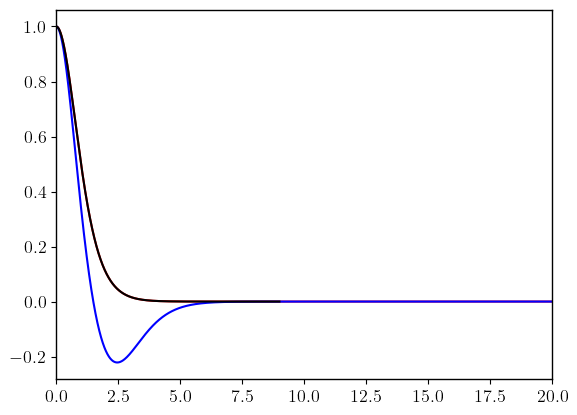

In [4]:
delta_x = 0.00001
rval = np.arange(len(f))*delta_x

# graficando
plt.plot(xn0, fn0, 'red')
plt.plot(xn1, fn1, 'blue')
plt.plot(rval, f, 'k')

plt.xlim(0, 20)

In [5]:
# Example
alpha = lambda massC, mass : (massC / mass) ** 2

num_threads = multiprocessing.cpu_count()

simulation_parameters = {
  "lambda_value": 0, 
  "num_threads": num_threads, 
  "gridlength": 20,
  "resol": 128, 
  "step_factor": 1., 
  "t0": 0, 
  "tmax": 100,
  "Plim": 5.6,
  "rmax": 7.6,
  "cmass": 0, 
  "plott0": False,
  "Boverlap": False, 
  "info" : False
}
    
salva_data = {
  "format": "npz", 
  "address": "Data", 
  "save_number": 20,
  "data_save" : {"grid": True,
                 "save_rho": False,
                 "save_psi": False,
                 "save_phi": True,
                 "save_plane": True,
                 "save_energies": None,
                 "save_line": True}
}



# For the components
compfield = 1 # 2
# profiles
sol1 = [f] #[fn0, fn0]
sol2 = [f] #[fn1, fn1]

# betas
beta1 = [En0] #[En0, En0]
beta2 = [En0] #[En1, En1]


# For the configuration
# positions
csol1 = [0., 0., 0.]
csol2 = [-4., 0., 0.]

# velocity
vsol1 = [0., 0., 0.]
vsol2 = [0., 0., 0.]

# phases
phase1 = [0] 
phase2 = [0]

# alphas (will be a float)
alpha1 = [alpha(8, Mn0)]
alpha2 = [alpha(3, Mn0)]

# dx
delta_x = 0.00001
dr1 = [delta_x]
dr2 = [delta_x]

parameters_sol = [{"profiles": sol1, "positions": csol1, "velocities": vsol1, 
                    "betas": beta1, "phases": phase1, "alphas": alpha1, "dr": dr1},
                  {"profiles": sol2, "positions": csol2, "velocities": vsol2, 
                    "betas": beta2, "phases": phase2, "alphas": alpha2, "dr": dr2}
                  ]

model = "soliton"

# iniciando simulación
rhoF, phispF = eu.evolve( model,
           model_parameters=parameters_sol,
           field_components=compfield,
           salva_data_update=salva_data,
           simulation_parameters_update=simulation_parameters,
           info=False)

Progress: [####################] 100%
 All data was save


Complete. Total time ->  639.9957802295685
save_frames 21 

2920.311290413902


None

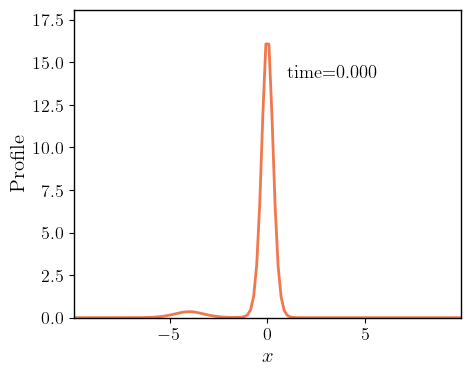

In [6]:
#Example of 2D video

#address = "Data_Est_n0_n0"
figData = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

address = salva_data['address']
dvideo = eu.Visualization(address, figData)  # creando el objeto

n0 = 0  # begin frame
nameP = "save_line"
struc = ['-', 2, '#f0784d']
nameV = 'lin_dens'
coord = ['x']

video = dvideo.video(nameP, struc, nameV, coord=coord, 
                     xlim=None, ylim=None,
                     show=False, n0=n0, plot2D=True, 
                     plot3D=False, save=True)
display(video)

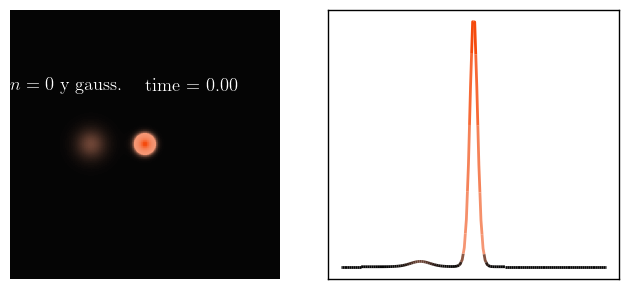

None

In [7]:
# Example of 2D video

#address = "Data_Est_n0_n0"
figData = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

dvideo = eu.Visualization(address, figData)  # creando el objeto

n0 = 0  # begin frame
nameP = "save_line"
name2 = "save_plane"
struc = ['-', 2, '#f0784d']
nameV = 'region_dens2'
coord = ['x']
cmapint=[(0, '#050505'),
         (0.05, '#f59876'),
         (0.5, '#f57d51'),
         (0.75, '#f76834'),
          (1, '#f54a0c')]
vconf = [10, 1000000, ['-vcodec', 'libx264']]

text = r'$n=0$ y gauss.'

video = dvideo.video(nameP, struc, nameV, name2=name2, cmapint=cmapint,
                     coord=coord, show=True, n0=n0, plot2D=True, plot3D=False,
                     vconf=vconf, save=True,
                     xlim=(-1, 1), ylim=(-1, 1), text=text)
display(video)

In [7]:
# Graficando algunos datos
import os

In [8]:
address = salva_data["address"]
format = salva_data["format"]
save_number = salva_data["save_number"]

# Identificando nombres
filenames = eu.nameData(address, format, info=True)
filenames

Se encontraron 4 archivos con la extensión .npz


['end_save_line.npz', 'end_save_plane.npz', 'end_save_phi.npz', 'end_grid.npz']

In [42]:
# extracting the grid coordinates
temp = np.load(address + f"/{filenames[-1]}")
grid = [temp[cord] for cord in ['x', 'y', 'z']]
# grid

In [43]:
# extracting the x-proyection of rho
temp = np.load(address + f"/{filenames[0]}")
lrho = [temp['save_line%s'%num] for num in range(0, save_number+1)]

temp = np.load(address + f"/{filenames[1]}")
planerho = [temp['save_plane%s'%num] for num in range(0, save_number+1)]

temp = np.load(address + f"/{filenames[2]}")
Upot = [temp['save_phi%s'%num] for num in range(0, save_number+1)]

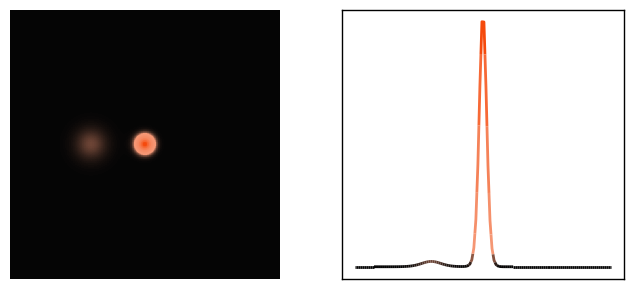

In [28]:
frame = 10
data = planerho[frame].T
da2 = [grid[0], lrho[frame]]

cmapint = [(0, '#050505'), (0.05, '#f59876'),
           (0.5, '#f57d51'), (0.75, '#f76834'),
           (1, '#f54a0c')]

eu.imagshow2D(data, da2, save=True, xlim=(-1, 1), ylim=(-1, 1), cmapint=cmapint)

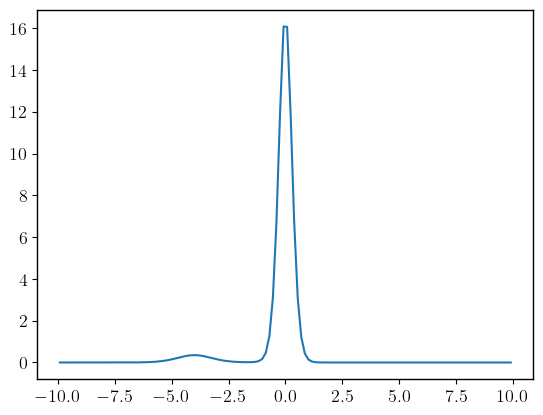

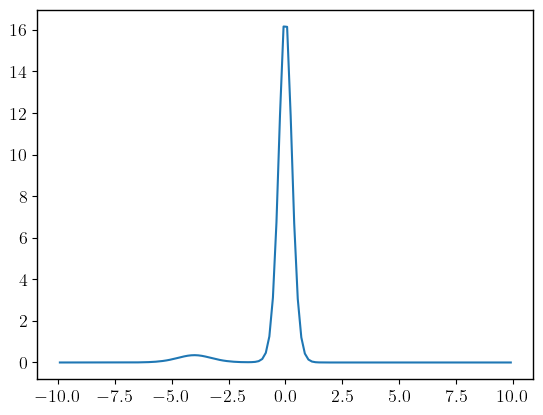

In [45]:
for ind in range(2):
    rho = lrho[ind]
    xd = grid[0]

    plt.plot(xd, rho)
    plt.show()

In [ ]:
#ind = 3
for ind in range(1):
    rho = planerho[ind]
    phisp = Upot[ind]
    xd, yd = grid[0], grid[1]
    cxd, cyd = 'x', 'y'

    sc.PlaneProf(rho, xd, yd, cxd, cyd, save=False)
    sc.PlaneProf(phisp[:, :, int(resol/2)], xd, yd, cxd, cyd, save=False)

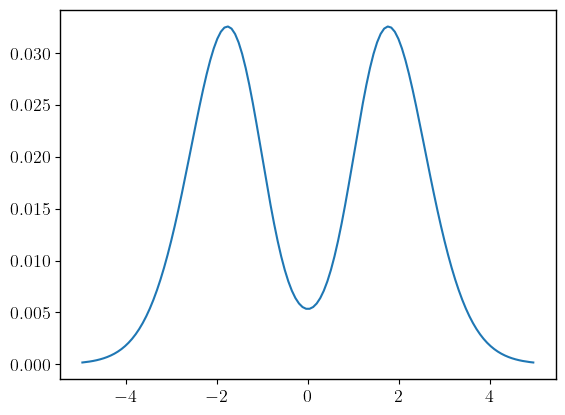

In [24]:
resol = simulation_parameters['resol']
y = rho[:, resol // 2, resol // 2]

plt.plot(xarray.flatten(), y[1])

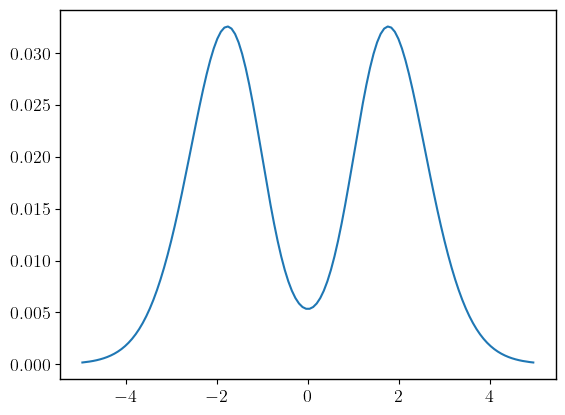

In [19]:
resol = simulation_parameters['resol']
y = rho[:, resol // 2, resol // 2]

plt.plot(xarray.flatten(), y[0])

In [ ]:
# Simulación con numba
alpha = lambda massC, mass : (massC / mass) ** 2

# Parametros simulación
Plim = 5.6  # filtro del perfil
rmax = 7.6
t0, tmax = 0, 100

# Set number of threads to target
num_threads = multiprocessing.cpu_count()

# grid
gridlength = 20
resol = 128
save_number = 20

# Modelo
cmass = 0
#modelo=msol.SoliIncProf
# Soliton parameters

dataname = ["alpha", "position", "velocity", "phase", "beta"]
#soliton1 = [4.244682324990256, [r, 0, 0], [0, 0, 0], 0, 2.454]
#soliton2 = [0.5969084519517548, [-r, 0, 0], [0, 0, 0], 0, 2.454]

soliton1 = [alpha(8, Mn0), [0, 0, 0], [0, 0, 0], 0, En0]
soliton2 = [alpha(3, Mn0), [-4, 0, 0], [0, 0, 0], 0, En0]
profiles = [f, f]
delta_x = 0.00001

Data_solitons = [dict(zip(dataname, i)) for i in [soliton1, soliton2]]


# Save
address = "Data_Est_n0_n0"
format = "npz"
data_save = {"grid": True,
            "save_rho": False,
            "save_psi": False,
            "save_phi": True,
            "save_plane": True,
            "save_energies": None,
            "save_line": True}


# iniciando simulación
rhoF, phispF = eu.evolve(Data_IniProfile=Data_solitons, profiles=profiles, num_threads=num_threads, 
                        gridlength=gridlength, resol=resol, step_factor=1., save_number=save_number,
                        rmax=rmax, Plim=Plim, t0=t0, tmax=tmax, cmass=cmass, plott0=True, info=False,
                        Boverlap=False, address=address, format=format, data_save=data_save, delta_x=delta_x)

In [15]:
import pyfftw

In [16]:
t1 = np.array([[[[1,2, 1], [2,0, 1], [2,0, 1]],
                [[1,2, 1], [0,9, 1], [0,9, 1]],
                [[1,3,1], [1,0,1], [1,0,1]]],
               [[[1,1, 2], [2,0,1], [2,0,1]],
                [[1,2,1], [0,9,1],  [0,9,1]],
                [[1,3,1], [1,0,1], [1,3,1]]]])
t1.shape

(2, 3, 3, 3)

In [17]:
psi = pyfftw.zeros_aligned((2, 3, 3, 3), dtype='complex128')
psi3d = pyfftw.zeros_aligned((3, 3, 3), dtype='complex128')

In [18]:
fft_psi = pyfftw.builders.fftn(psi, axes=(1, 2, 3), threads=num_threads)
fft_psi3D = pyfftw.builders.fftn(psi3d, axes=(0, 1, 2), threads=num_threads)
fft_psi3D2 = pyfftw.builders.fftn(psi3d, axes=(0, 1, 2), threads=num_threads)

In [19]:
test0 = fft_psi3D(t1[0])
test1 = fft_psi3D2(t1[1])
testF = fft_psi(t1)

In [20]:
testF[0]

array([[[ 43.  +0.j        ,  -8. -13.85640646j,  -8. +13.85640646j],
        [ -2.  +0.j        ,   1.  +1.73205081j,   1.  -1.73205081j],
        [ -2.  +0.j        ,   1.  +1.73205081j,   1.  -1.73205081j]],

       [[ -6.5-12.99038106j,  -5. +17.32050808j,  20.5 +0.8660254j ],
        [  2.5 +7.79422863j,   4.  -8.66025404j, -11.  -1.73205081j],
        [  2.5 +7.79422863j,   4.  -8.66025404j, -11.  -1.73205081j]],

       [[ -6.5+12.99038106j,  20.5 -0.8660254j ,  -5. -17.32050808j],
        [  2.5 -7.79422863j, -11.  +1.73205081j,   4.  +8.66025404j],
        [  2.5 -7.79422863j, -11.  +1.73205081j,   4.  +8.66025404j]]])

In [21]:
test0

array([[[ 43.  +0.j        ,  -8. -13.85640646j,  -8. +13.85640646j],
        [ -2.  +0.j        ,   1.  +1.73205081j,   1.  -1.73205081j],
        [ -2.  +0.j        ,   1.  +1.73205081j,   1.  -1.73205081j]],

       [[ -6.5-12.99038106j,  -5. +17.32050808j,  20.5 +0.8660254j ],
        [  2.5 +7.79422863j,   4.  -8.66025404j, -11.  -1.73205081j],
        [  2.5 +7.79422863j,   4.  -8.66025404j, -11.  -1.73205081j]],

       [[ -6.5+12.99038106j,  20.5 -0.8660254j ,  -5. -17.32050808j],
        [  2.5 -7.79422863j, -11.  +1.73205081j,   4.  +8.66025404j],
        [  2.5 -7.79422863j, -11.  +1.73205081j,   4.  +8.66025404j]]])

In [22]:
testF[1]

array([[[ 46.  +0.j        ,  -9.5-14.72243186j,  -9.5+14.72243186j],
        [ -3.5 +2.59807621j,   4.  +3.46410162j,  -0.5 -6.06217783j],
        [ -3.5 -2.59807621j,  -0.5 +6.06217783j,   4.  -3.46410162j]],

       [[ -8. -10.39230485j,  -2. +19.05255888j,  19.  -3.46410162j],
        [  1.  +5.19615242j,   2.5 -4.33012702j,  -8.  -3.46410162j],
        [  5.5 +7.79422863j,   2.5 -9.52627944j, -12.5 -0.8660254j ]],

       [[ -8. +10.39230485j,  19.  +3.46410162j,  -2. -19.05255888j],
        [  5.5 -7.79422863j, -12.5 +0.8660254j ,   2.5 +9.52627944j],
        [  1.  -5.19615242j,  -8.  +3.46410162j,   2.5 +4.33012702j]]])

In [23]:
test1

array([[[ 46.  +0.j        ,  -9.5-14.72243186j,  -9.5+14.72243186j],
        [ -3.5 +2.59807621j,   4.  +3.46410162j,  -0.5 -6.06217783j],
        [ -3.5 -2.59807621j,  -0.5 +6.06217783j,   4.  -3.46410162j]],

       [[ -8. -10.39230485j,  -2. +19.05255888j,  19.  -3.46410162j],
        [  1.  +5.19615242j,   2.5 -4.33012702j,  -8.  -3.46410162j],
        [  5.5 +7.79422863j,   2.5 -9.52627944j, -12.5 -0.8660254j ]],

       [[ -8. +10.39230485j,  19.  +3.46410162j,  -2. -19.05255888j],
        [  5.5 -7.79422863j, -12.5 +0.8660254j ,   2.5 +9.52627944j],
        [  1.  -5.19615242j,  -8.  +3.46410162j,   2.5 +4.33012702j]]])

In [24]:
test1

array([[[ 46.  +0.j        ,  -9.5-14.72243186j,  -9.5+14.72243186j],
        [ -3.5 +2.59807621j,   4.  +3.46410162j,  -0.5 -6.06217783j],
        [ -3.5 -2.59807621j,  -0.5 +6.06217783j,   4.  -3.46410162j]],

       [[ -8. -10.39230485j,  -2. +19.05255888j,  19.  -3.46410162j],
        [  1.  +5.19615242j,   2.5 -4.33012702j,  -8.  -3.46410162j],
        [  5.5 +7.79422863j,   2.5 -9.52627944j, -12.5 -0.8660254j ]],

       [[ -8. +10.39230485j,  19.  +3.46410162j,  -2. -19.05255888j],
        [  5.5 -7.79422863j, -12.5 +0.8660254j ,   2.5 +9.52627944j],
        [  1.  -5.19615242j,  -8.  +3.46410162j,   2.5 +4.33012702j]]])

In [25]:
t1[1]

array([[[1, 1, 2],
        [2, 0, 1],
        [2, 0, 1]],

       [[1, 2, 1],
        [0, 9, 1],
        [0, 9, 1]],

       [[1, 3, 1],
        [1, 0, 1],
        [1, 3, 1]]])

In [26]:
t1[1][0, 0] = [0,0,0]

In [27]:
t1[1]

array([[[0, 0, 0],
        [2, 0, 1],
        [2, 0, 1]],

       [[1, 2, 1],
        [0, 9, 1],
        [0, 9, 1]],

       [[1, 3, 1],
        [1, 0, 1],
        [1, 3, 1]]])

In [28]:
test1 = fft_psi3D2(t1[1])

In [29]:
import numexpr as ne

In [43]:
testF[0]

array([[[ 43.  +0.j        ,  -8. -13.85640646j,  -8. +13.85640646j],
        [ -2.  +0.j        ,   1.  +1.73205081j,   1.  -1.73205081j],
        [ -2.  +0.j        ,   1.  +1.73205081j,   1.  -1.73205081j]],

       [[ -6.5-12.99038106j,  -5. +17.32050808j,  20.5 +0.8660254j ],
        [  2.5 +7.79422863j,   4.  -8.66025404j, -11.  -1.73205081j],
        [  2.5 +7.79422863j,   4.  -8.66025404j, -11.  -1.73205081j]],

       [[ -6.5+12.99038106j,  20.5 -0.8660254j ,  -5. -17.32050808j],
        [  2.5 -7.79422863j, -11.  +1.73205081j,   4.  +8.66025404j],
        [  2.5 -7.79422863j, -11.  +1.73205081j,   4.  +8.66025404j]]])

In [30]:
psi = np.array([[[1, 2, 1],
                 [2,0, 1],
                 [2,0, 1]],
                [[1,2, 1],
                 [0,9, 1],
                 [0,9, 1]],
                [[1,3,1],
                 [1,0,1],
                 [1,0,1]]])
psi.shape

(3, 3, 3)

In [37]:
res = ne.evaluate("psi * testF")

In [38]:
print(testF.shape, res.shape)

(2, 3, 3, 3) (2, 3, 3, 3)


In [39]:
res

array([[[[ 43.  +0.j        , -16. -27.71281292j,  -8. +13.85640646j],
         [ -4.  +0.j        ,   0.  +0.j        ,   1.  -1.73205081j],
         [ -4.  +0.j        ,   0.  +0.j        ,   1.  -1.73205081j]],

        [[ -6.5-12.99038106j, -10. +34.64101615j,  20.5 +0.8660254j ],
         [  0.  +0.j        ,  36. -77.94228634j, -11.  -1.73205081j],
         [  0.  +0.j        ,  36. -77.94228634j, -11.  -1.73205081j]],

        [[ -6.5+12.99038106j,  61.5 -2.59807621j,  -5. -17.32050808j],
         [  2.5 -7.79422863j,  -0.  +0.j        ,   4.  +8.66025404j],
         [  2.5 -7.79422863j,  -0.  +0.j        ,   4.  +8.66025404j]]],


       [[[ 46.  +0.j        , -19. -29.44486373j,  -9.5+14.72243186j],
         [ -7.  +5.19615242j,   0.  +0.j        ,  -0.5 -6.06217783j],
         [ -7.  -5.19615242j,  -0.  +0.j        ,   4.  -3.46410162j]],

        [[ -8. -10.39230485j,  -4. +38.10511777j,  19.  -3.46410162j],
         [  0.  +0.j        ,  22.5-38.97114317j,  -8.  -3.46410162

In [36]:
psi * testF

array([[[[ 43.  +0.j        , -16. -27.71281292j,  -8. +13.85640646j],
         [ -4.  +0.j        ,   0.  +0.j        ,   1.  -1.73205081j],
         [ -4.  +0.j        ,   0.  +0.j        ,   1.  -1.73205081j]],

        [[ -6.5-12.99038106j, -10. +34.64101615j,  20.5 +0.8660254j ],
         [  0.  +0.j        ,  36. -77.94228634j, -11.  -1.73205081j],
         [  0.  +0.j        ,  36. -77.94228634j, -11.  -1.73205081j]],

        [[ -6.5+12.99038106j,  61.5 -2.59807621j,  -5. -17.32050808j],
         [  2.5 -7.79422863j,  -0.  +0.j        ,   4.  +8.66025404j],
         [  2.5 -7.79422863j,  -0.  +0.j        ,   4.  +8.66025404j]]],


       [[[ 46.  +0.j        , -19. -29.44486373j,  -9.5+14.72243186j],
         [ -7.  +5.19615242j,   0.  +0.j        ,  -0.5 -6.06217783j],
         [ -7.  -5.19615242j,  -0.  +0.j        ,   4.  -3.46410162j]],

        [[ -8. -10.39230485j,  -4. +38.10511777j,  19.  -3.46410162j],
         [  0.  +0.j        ,  22.5-38.97114317j,  -8.  -3.46410162